In [1]:
# Cell 2 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os
warnings.filterwarnings('ignore')

# Output folders
os.makedirs('../reports/png', exist_ok=True)
os.makedirs('../reports/html', exist_ok=True)

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print('Libraries loaded!')

Libraries loaded!


In [2]:
# Cell 3 – Load cleaned dataset from Task 1
df = pd.read_csv('../data/cleaned_superstore.csv')

# Ensure date columns are parsed
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Derived columns
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.to_period('M').astype(str)
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (6764, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,2016,2016-11,16.00
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714,2016,2016-06,47.00
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164,2015,2015-10,11.25


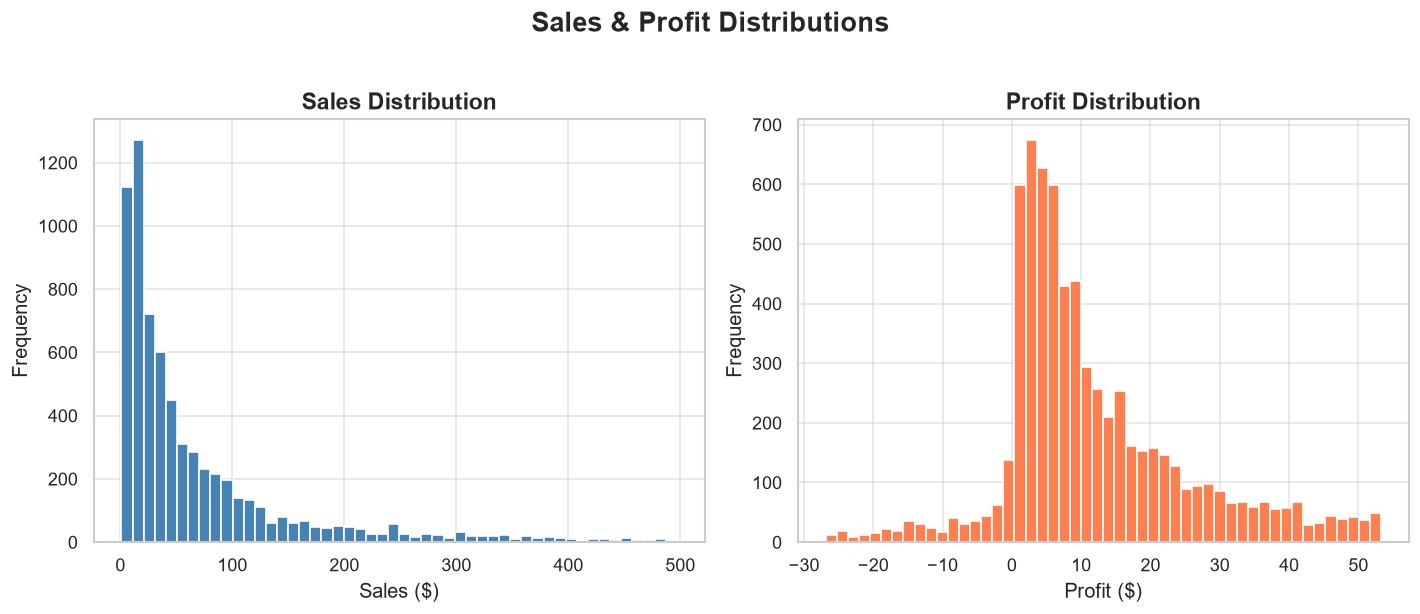

Saved: 01_sales_profit_distribution.png


In [3]:
# Cell 4 – Histogram: Sales Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Profit'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Profit Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Sales & Profit Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/png/01_sales_profit_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 01_sales_profit_distribution.png')

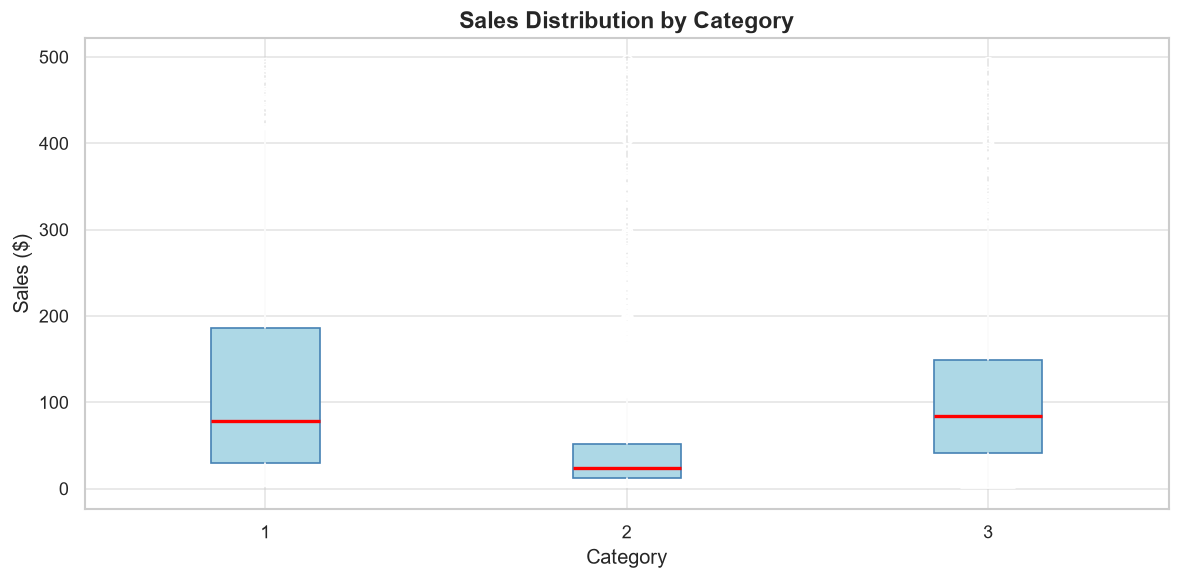

Saved: 02_boxplot_sales_by_category.png


In [4]:
# Cell 5 – Boxplot: Sales by Category
fig, ax = plt.subplots(figsize=(10, 5))

categories = df['Category'].unique()
data_by_cat = [df[df['Category'] == c]['Sales'].values for c in categories]
bp = ax.boxplot(data_by_cat, label =categories, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))

ax.set_title('Sales Distribution by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../reports/png/02_boxplot_sales_by_category.png', bbox_inches='tight')
plt.show()
print('Saved: 02_boxplot_sales_by_category.png')

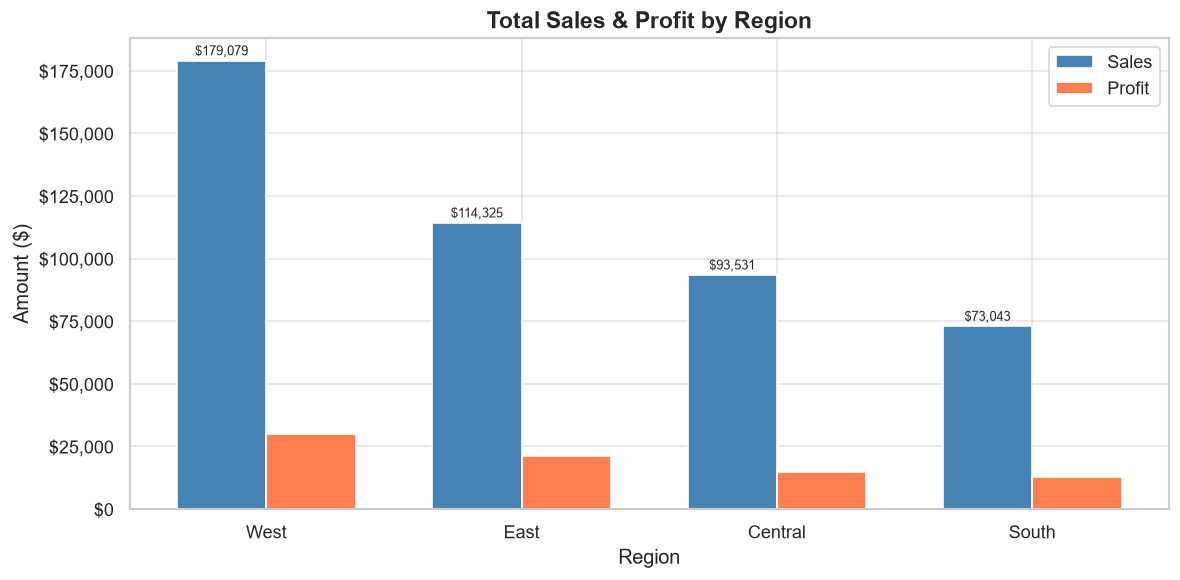

Saved: 03_bar_sales_profit_by_region.png


In [5]:
# Cell 6 – Bar Chart: Total Sales & Profit by Region
region_df = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index().sort_values('Sales', ascending=False)

x = np.arange(len(region_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, region_df['Sales'],   width, label='Sales',  color='steelblue')
bars2 = ax.bar(x + width/2, region_df['Profit'],  width, label='Profit', color='coral')

ax.set_title('Total Sales & Profit by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(region_df['Region'])
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/png/03_bar_sales_profit_by_region.png', bbox_inches='tight')
plt.show()
print('Saved: 03_bar_sales_profit_by_region.png')

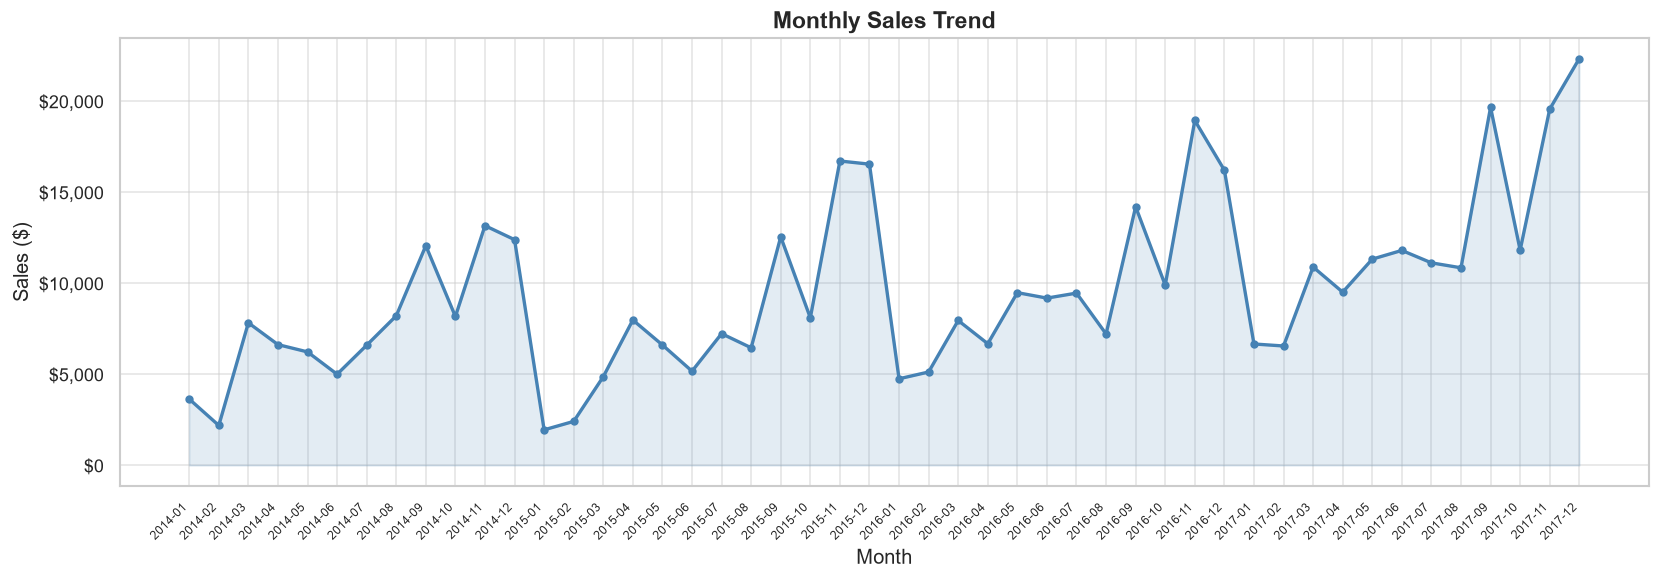

Saved: 04_line_monthly_sales_trend.png


In [6]:
# Cell 7 – Line Chart: Monthly Sales Trend
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly = monthly.sort_values('Month')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], monthly['Sales'], marker='o', color='steelblue',
        linewidth=2, markersize=4)
ax.fill_between(monthly['Month'], monthly['Sales'], alpha=0.15, color='steelblue')

ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('../reports/png/04_line_monthly_sales_trend.png', bbox_inches='tight')
plt.show()
print('Saved: 04_line_monthly_sales_trend.png')

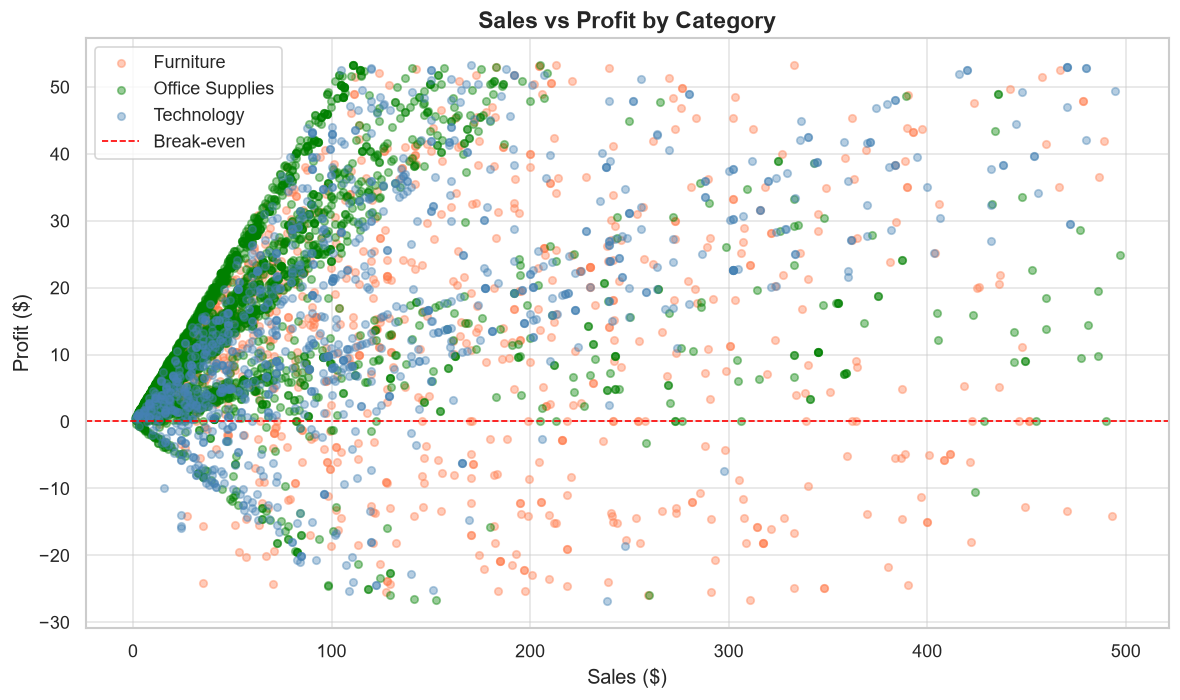

Saved: 05_scatter_sales_vs_profit.png


In [7]:
# Cell 8 – Scatter Plot: Sales vs Profit by Category
colors = {'Technology': 'steelblue', 'Furniture': 'coral', 'Office Supplies': 'green'}

fig, ax = plt.subplots(figsize=(10, 6))
for cat, grp in df.groupby('Category'):
    ax.scatter(grp['Sales'], grp['Profit'], alpha=0.4, s=20,
               label=cat, color=colors.get(cat, 'grey'))

ax.axhline(0, color='red', linewidth=1, linestyle='--', label='Break-even')
ax.set_title('Sales vs Profit by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/png/05_scatter_sales_vs_profit.png', bbox_inches='tight')
plt.show()
print('Saved: 05_scatter_sales_vs_profit.png')

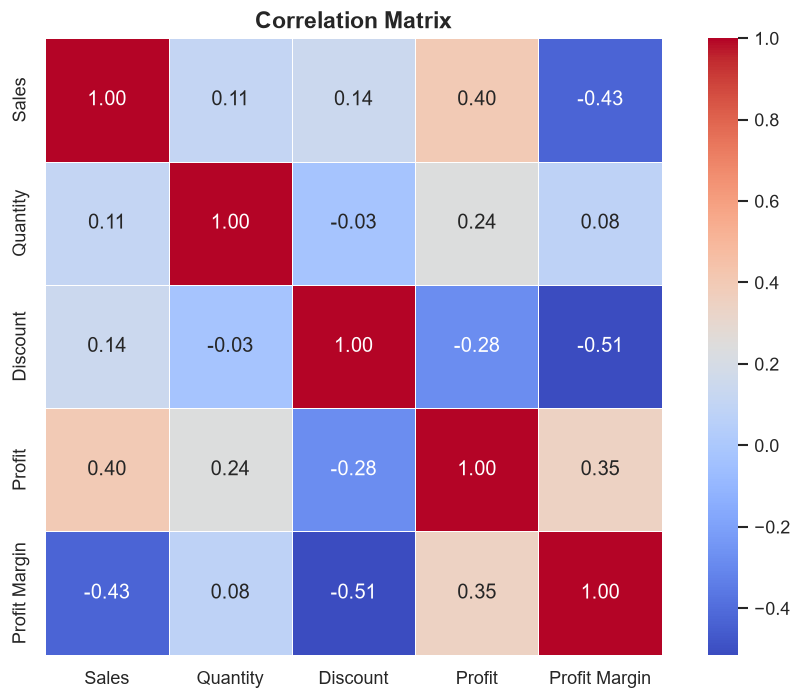

Saved: 06_heatmap_correlation.png


In [8]:
# Cell 9 – Heatmap: Correlation Matrix
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/png/06_heatmap_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: 06_heatmap_correlation.png')

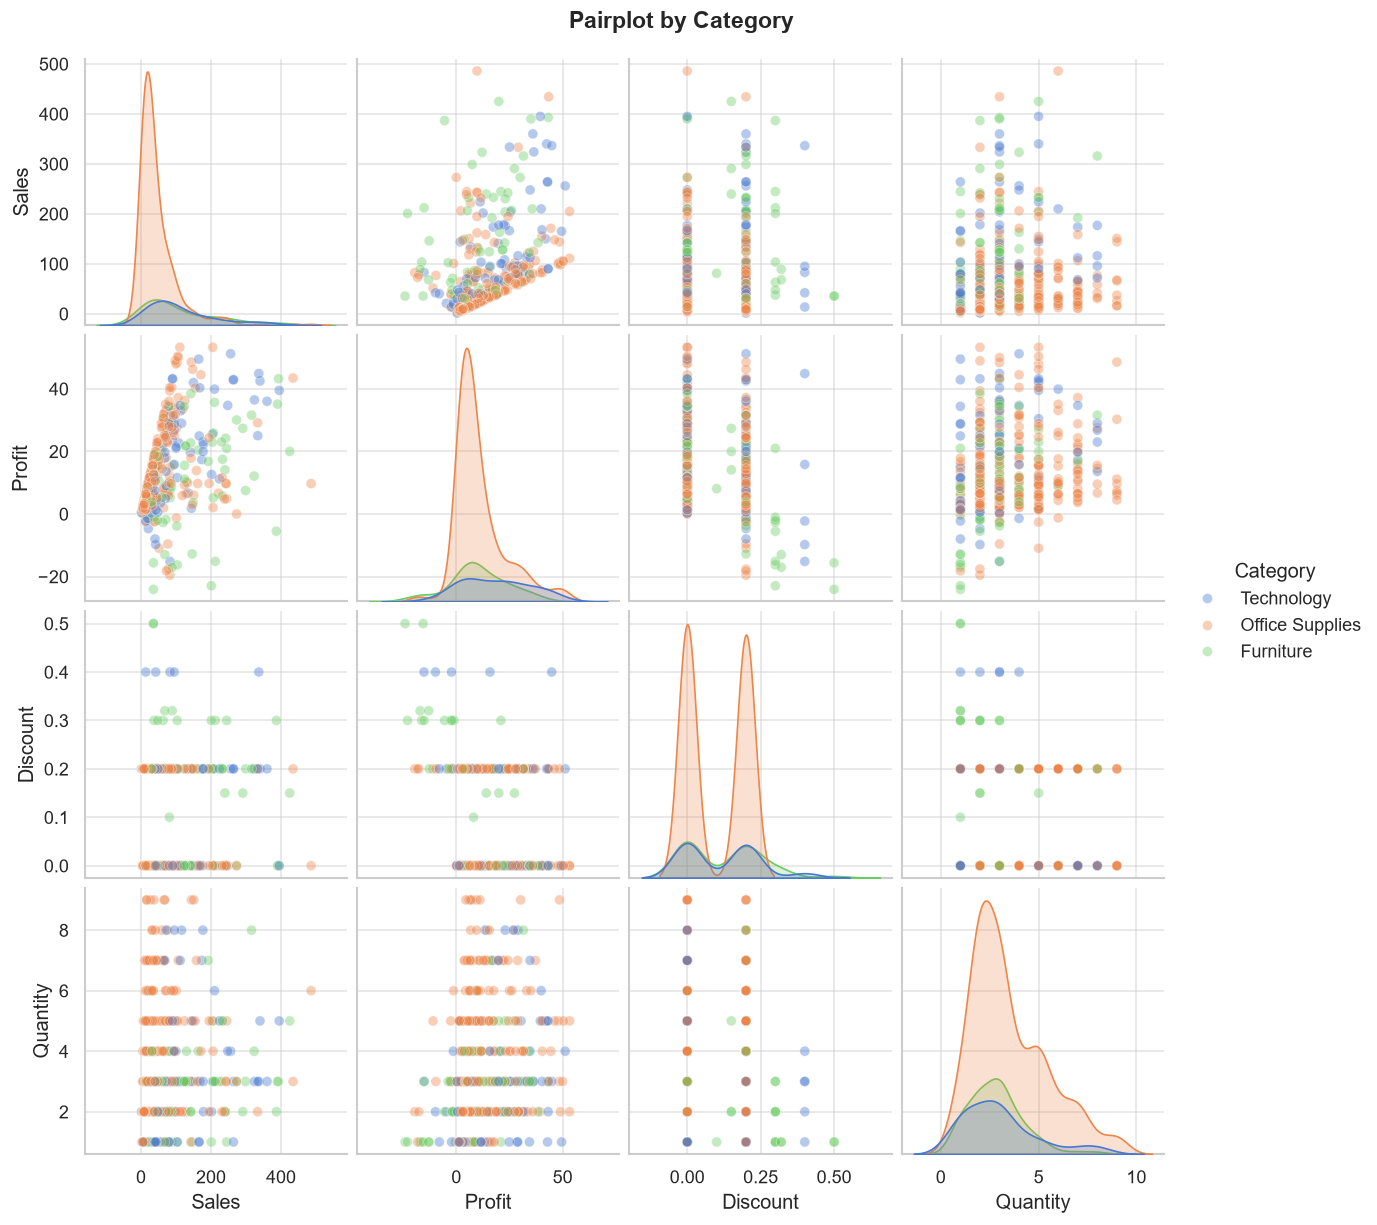

Saved: 07_pairplot_by_category.png


In [9]:
# Cell 10 – Pairplot: Numeric variables by Category
pair_df = df[['Sales', 'Profit', 'Discount', 'Quantity', 'Category']].sample(500, random_state=42)
g = sns.pairplot(pair_df, hue='Category', plot_kws={'alpha': 0.4}, diag_kind='kde')
g.figure.suptitle('Pairplot by Category', y=1.02, fontsize=14, fontweight='bold')
g.savefig('../reports/png/07_pairplot_by_category.png')
plt.show()
print('Saved: 07_pairplot_by_category.png')

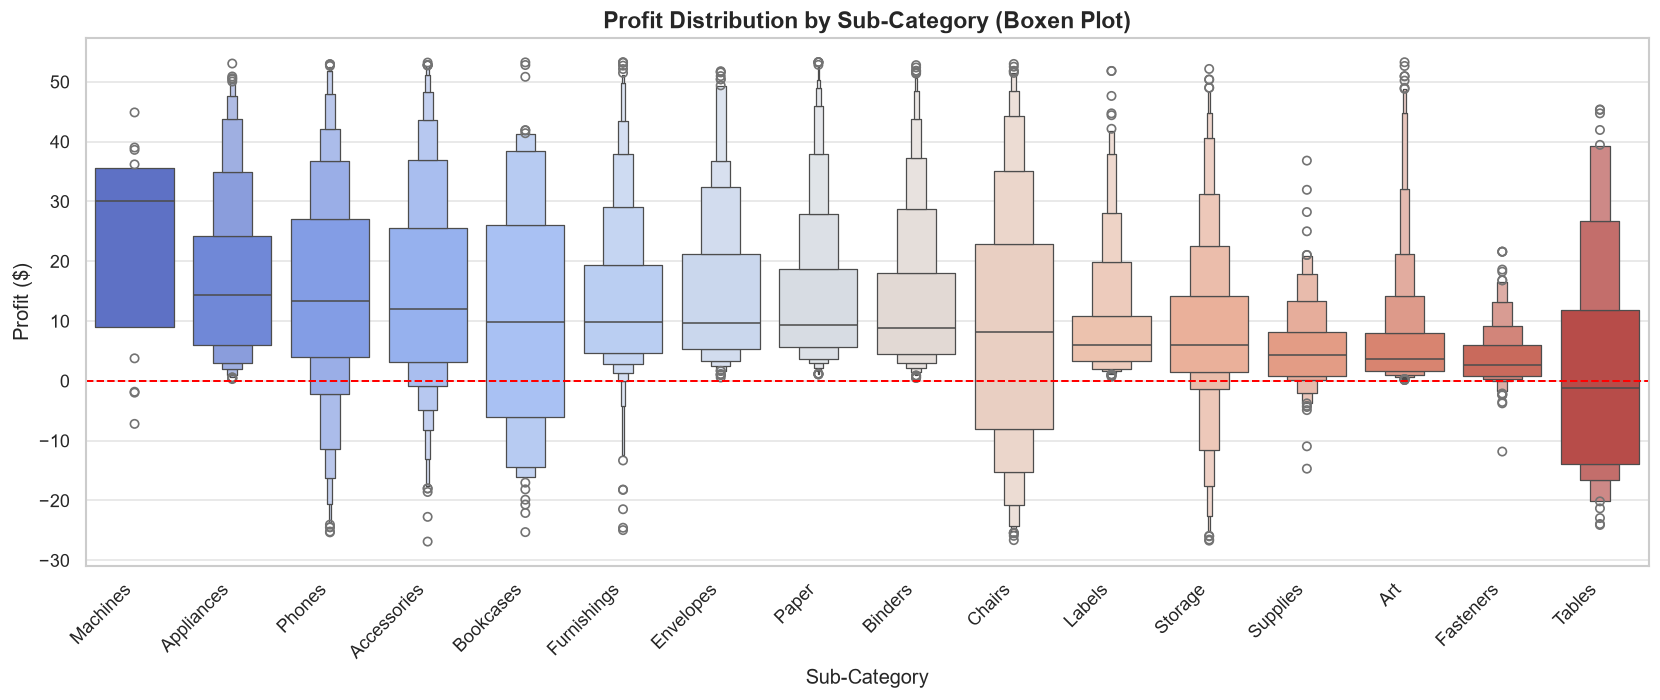

Saved: 08_boxenplot_profit_by_subcategory.png


In [10]:
# Cell 11 – Boxen Plot: Profit by Sub-Category
fig, ax = plt.subplots(figsize=(14, 6))
subcat_order = df.groupby('Sub-Category')['Profit'].median().sort_values(ascending=False).index

sns.boxenplot(data=df, x='Sub-Category', y='Profit',
              order=subcat_order, palette='coolwarm', ax=ax)
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_title('Profit Distribution by Sub-Category (Boxen Plot)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/png/08_boxenplot_profit_by_subcategory.png', bbox_inches='tight')
plt.show()
print('Saved: 08_boxenplot_profit_by_subcategory.png')

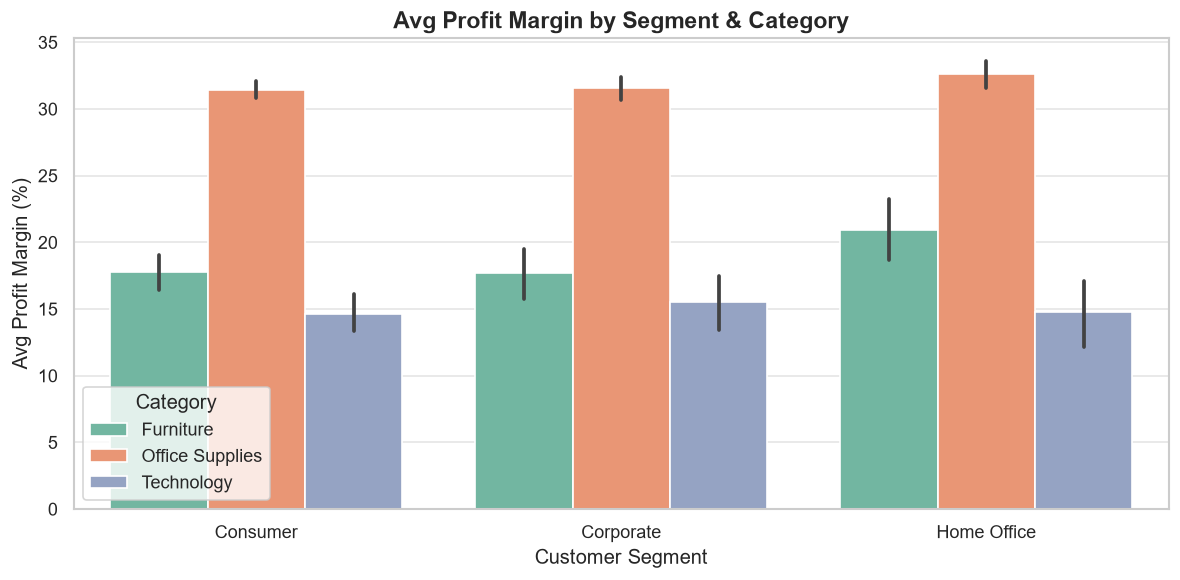

Saved: 09_barplot_margin_segment_category.png


In [11]:
# Cell 12 – Seaborn Bar: Avg Profit Margin by Segment & Category
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='Segment', y='Profit Margin',
            hue='Category', palette='Set2', ax=ax)
ax.set_title('Avg Profit Margin by Segment & Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Avg Profit Margin (%)')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('../reports/png/09_barplot_margin_segment_category.png', bbox_inches='tight')
plt.show()
print('Saved: 09_barplot_margin_segment_category.png')

In [12]:
# Cell 13 – Plotly Line: Monthly Sales Trend (Interactive)
monthly_cat = df.groupby(['Month', 'Category'])['Sales'].sum().reset_index()
monthly_cat = monthly_cat.sort_values('Month')

fig = px.line(monthly_cat, x='Month', y='Sales', color='Category',
              title='Monthly Sales Trend by Category',
              labels={'Sales': 'Total Sales ($)', 'Month': 'Month'},
              template='plotly_white', markers=True)
fig.update_layout(hovermode='x unified')
fig.write_html('../reports/html/01_plotly_monthly_sales_trend.html')
fig.show()
print('Saved: 01_plotly_monthly_sales_trend.html')

Saved: 01_plotly_monthly_sales_trend.html


In [13]:
# Cell 14 – Plotly Bar: Top 10 Sub-Categories by Sales
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
subcat_sales = subcat_sales.sort_values('Sales', ascending=False).head(10)

fig = px.bar(subcat_sales, x='Sales', y='Sub-Category',
             orientation='h', color='Sales',
             color_continuous_scale='Blues',
             title='Top 10 Sub-Categories by Sales',
             labels={'Sales': 'Total Sales ($)'},
             template='plotly_white')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html('../reports/html/02_plotly_top10_subcategories.html')
fig.show()
print('Saved: 02_plotly_top10_subcategories.html')

Saved: 02_plotly_top10_subcategories.html


In [14]:
# Cell 15 – Plotly Scatter: Sales vs Profit (Interactive)
fig = px.scatter(df, x='Sales', y='Profit',
                 color='Category', size='Quantity',
                 hover_data=['Product Name', 'Region', 'Discount'],
                 title='Sales vs Profit (Interactive)',
                 labels={'Sales': 'Sales ($)', 'Profit': 'Profit ($)'},
                 template='plotly_white', opacity=0.6)
fig.add_hline(y=0, line_dash='dash', line_color='red',
              annotation_text='Break-even')
fig.write_html('../reports/html/03_plotly_sales_vs_profit.html')
fig.show()
print('Saved: 03_plotly_sales_vs_profit.html')

Saved: 03_plotly_sales_vs_profit.html


In [15]:
# Cell 16 – Plotly Pie/Donut: Sales Share by Category
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()

fig = px.pie(cat_sales, values='Sales', names='Category',
             title='Sales Share by Category',
             hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Set2,
             template='plotly_white')
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.write_html('../reports/html/04_plotly_sales_share_donut.html')
fig.show()
print('Saved: 04_plotly_sales_share_donut.html')

Saved: 04_plotly_sales_share_donut.html


In [16]:
# Cell 17 – Plotly Map: Sales by US State
state_sales = df.groupby('State')['Sales'].sum().reset_index()

fig = px.choropleth(state_sales,
                    locations='State',
                    locationmode='USA-states',
                    color='Sales',
                    scope='usa',
                    color_continuous_scale='Blues',
                    title='Total Sales by US State',
                    labels={'Sales': 'Total Sales ($)'},
                    template='plotly_white')
fig.write_html('../reports/html/05_plotly_sales_by_state_map.html')
fig.show()
print('Saved: 05_plotly_sales_by_state_map.html')

Saved: 05_plotly_sales_by_state_map.html


In [17]:
# Cell 18 – Plotly Combined Dashboard (4 charts in one HTML)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Monthly Sales Trend', 'Sales by Category',
                    'Top 10 Sub-Categories', 'Profit by Region'),
    specs=[[{'type': 'scatter'}, {'type': 'pie'}],
           [{'type': 'bar'},    {'type': 'bar'}]]
)

# Chart 1: Monthly trend
m = df.groupby('Month')['Sales'].sum().reset_index().sort_values('Month')
fig.add_trace(go.Scatter(x=m['Month'], y=m['Sales'], mode='lines+markers',
                          name='Monthly Sales', line=dict(color='steelblue')), row=1, col=1)

# Chart 2: Category pie
c = df.groupby('Category')['Sales'].sum().reset_index()
fig.add_trace(go.Pie(labels=c['Category'], values=c['Sales'],
                      hole=0.4, name='Category'), row=1, col=2)

# Chart 3: Top 10 sub-categories
sc = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).reset_index()
fig.add_trace(go.Bar(x=sc['Sales'], y=sc['Sub-Category'],
                      orientation='h', name='Sub-Cat Sales',
                      marker_color='coral'), row=2, col=1)

# Chart 4: Profit by Region
r = df.groupby('Region')['Profit'].sum().reset_index()
fig.add_trace(go.Bar(x=r['Region'], y=r['Profit'],
                      name='Regional Profit',
                      marker_color='mediumseagreen'), row=2, col=2)

fig.update_layout(title_text='Superstore Sales Dashboard',
                  title_font_size=20, height=700,
                  showlegend=False, template='plotly_white')
fig.write_html('../reports/html/06_plotly_combined_dashboard.html')
fig.show()
print('Saved: 06_plotly_combined_dashboard.html')

Saved: 06_plotly_combined_dashboard.html


In [18]:
# Cell 19 – Summary of exported files
import glob

png_files  = sorted(glob.glob('../reports/png/*.png'))
html_files = sorted(glob.glob('../reports/html/*.html'))

print('PNG files exported:')
for f in png_files:  print(f'  {f}')
print(f'\nHTML files exported:')
for f in html_files: print(f'  {f}')

print(f'\nTotal: {len(png_files)} PNGs + {len(html_files)} HTMLs')

PNG files exported:
  ../reports/png\01_sales_profit_distribution.png
  ../reports/png\02_boxplot_sales_by_category.png
  ../reports/png\03_bar_sales_profit_by_region.png
  ../reports/png\04_line_monthly_sales_trend.png
  ../reports/png\05_scatter_sales_vs_profit.png
  ../reports/png\06_heatmap_correlation.png
  ../reports/png\07_pairplot_by_category.png
  ../reports/png\08_boxenplot_profit_by_subcategory.png
  ../reports/png\09_barplot_margin_segment_category.png

HTML files exported:
  ../reports/html\01_plotly_monthly_sales_trend.html
  ../reports/html\02_plotly_top10_subcategories.html
  ../reports/html\03_plotly_sales_vs_profit.html
  ../reports/html\04_plotly_sales_share_donut.html
  ../reports/html\05_plotly_sales_by_state_map.html
  ../reports/html\06_plotly_combined_dashboard.html

Total: 9 PNGs + 6 HTMLs
